# Phase 4 — Model Training & Evaluation
Run after `python scripts/run_phase4.py`.

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score
from src.evaluation.metrics import compute_metrics, print_metrics, plot_confusion_matrix
from src.evaluation.error_analysis import find_errors, error_summary

MODELS_PATH = Path('../models')
LABEL_NAMES = ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']

In [2]:
# Load test data
frames = []
for domain in ['amazon_reviews', 'tweets', 'financial_news']:
    p = Path(f'../data/splits/{domain}/test.csv')
    if p.exists():
        frames.append(pd.read_csv(p))
test_df = pd.concat(frames, ignore_index=True)
texts = test_df['text'].tolist()
labels = test_df['label'].tolist()
print(f'Test set: {len(test_df):,} samples')

Test set: 8,901 samples


## SVM + TF-IDF

[SVM + TF-IDF] Accuracy  : 0.4972
[SVM + TF-IDF] F1 Macro  : 0.4763
[SVM + TF-IDF] F1 Weighted: 0.4836
               precision    recall  f1-score   support

Very Negative       0.58      0.55      0.57      1468
     Negative       0.53      0.22      0.32      1412
      Neutral       0.50      0.37      0.43      1859
     Positive       0.45      0.57      0.50      2067
Very Positive       0.49      0.68      0.57      2095

     accuracy                           0.50      8901
    macro avg       0.51      0.48      0.48      8901
 weighted avg       0.50      0.50      0.48      8901



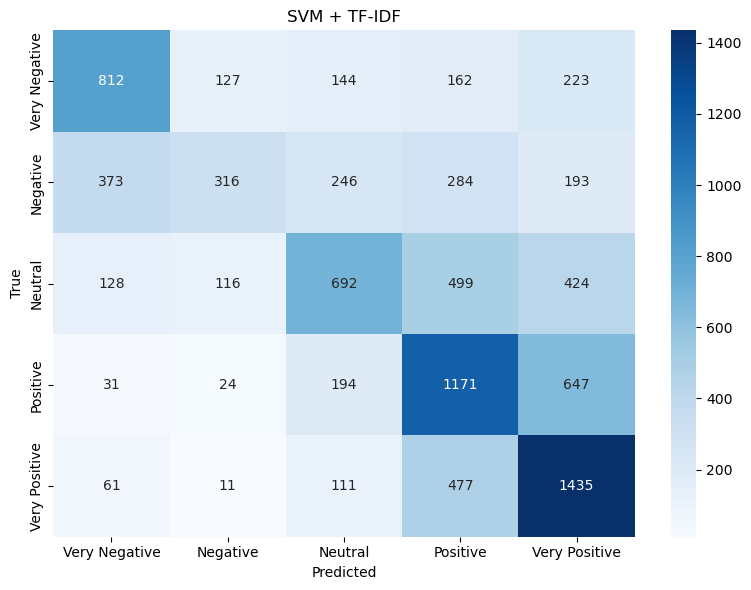

In [3]:
from src.models.svm_model import SVMClassifier
svm = SVMClassifier.load(MODELS_PATH / 'tfidf_svm.joblib')
svm_preds = svm.predict(texts)
m = compute_metrics(labels, svm_preds)
print_metrics(m, 'SVM + TF-IDF')
_ = plot_confusion_matrix(labels, svm_preds, 'SVM + TF-IDF')

## XGBoost + TF-IDF

[XGBoost + TF-IDF] Accuracy  : 0.5210
[XGBoost + TF-IDF] F1 Macro  : 0.5060
[XGBoost + TF-IDF] F1 Weighted: 0.5139
               precision    recall  f1-score   support

Very Negative       0.57      0.53      0.55      1468
     Negative       0.45      0.35      0.40      1412
      Neutral       0.45      0.36      0.40      1859
     Positive       0.49      0.66      0.56      2067
Very Positive       0.60      0.64      0.62      2095

     accuracy                           0.52      8901
    macro avg       0.51      0.51      0.51      8901
 weighted avg       0.52      0.52      0.51      8901



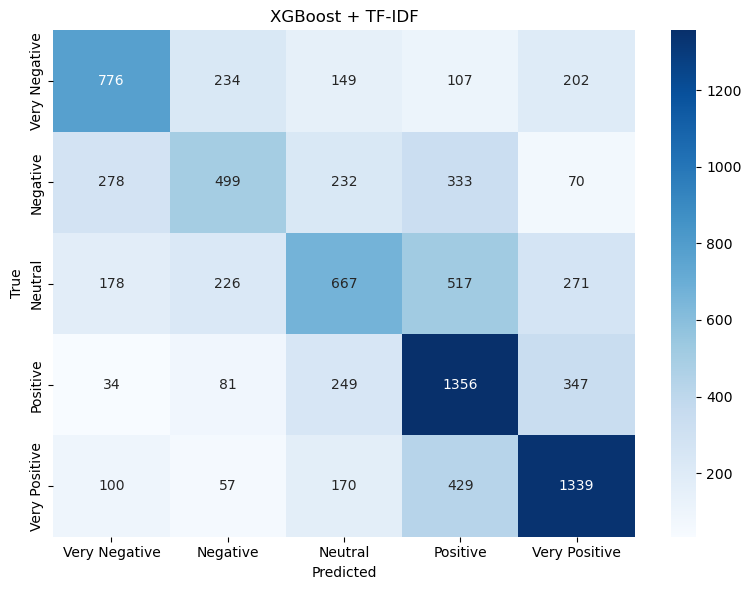

In [4]:
from src.models.xgboost_model import XGBoostClassifier
xgb = XGBoostClassifier.load(MODELS_PATH / 'tfidf_xgboost.joblib')
xgb_preds = xgb.predict(texts)
m = compute_metrics(labels, xgb_preds)
print_metrics(m, 'XGBoost + TF-IDF')
_ = plot_confusion_matrix(labels, xgb_preds, 'XGBoost + TF-IDF')

## Error analysis (SVM)

In [5]:
errors = find_errors(texts, labels, svm_preds.tolist(), top_n=10)
errors[['true_label', 'pred_label', 'error_magnitude', 'text']].head(10)

,true_label,pred_label,error_magnitude,text
0,Very Negative,Very Positive,4,@user how excited i was because dec 9th i was ...
1,Very Negative,Very Positive,4,"Recent rally could be a 'bear market trap,' sa..."
2,Very Negative,Very Positive,4,My mom's over here tryna tell me that we're ta...
3,Very Negative,Very Positive,4,$AYX - Alteryx Stock Price: More Downside Befo...
4,Very Negative,Very Positive,4,Vans parent VF Corp. says China stores still o...
5,Very Positive,Very Negative,4,I used to live in San Diego back in the early ...
6,Very Negative,Very Positive,4,I went to Dr Maebin because dr. Brown was on a...
7,Very Positive,Very Negative,4,I've been taking my cars to KCM for multiple y...
8,Very Negative,Very Positive,4,Seen a advert for today's Saturday kitchen ......
9,Very Negative,Very Positive,4,"""In the Ultimate Trap Game, Brian Kelly DID NO..."
